# Deletion World Evaluation Analysis

This notebook analyzes deletion-vs-baseline evaluation results, including utility trade-off and time-gap effects.


In [7]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)


In [8]:
# Paths (prefer relative paths; fallback to common names)
from pathlib import Path
source_dir = Path("/mnt/yao_data/proj_2026_agent/PersonaMem-main")
candidates_eval = [
    source_dir / 'data/deletion/gpt-51_deletion_eval_results.csv',
    source_dir / 'data/deletion/deletion_eval_results.csv',
]
candidates_spec = [
    source_dir / 'data/deletion/deletion_qa_specs.jsonl',
]
candidates_summary = [
    source_dir / 'data/deletion/gpt-51_deletion_eval_summary.json',
    source_dir / 'data/deletion/deletion_eval_summary.json',
]

def pick_existing(cands):
    for c in cands:
        if c.exists():
            return c
    return cands[0]

eval_csv = pick_existing(candidates_eval)
spec_jsonl = pick_existing(candidates_spec)
summary_json = pick_existing(candidates_summary)

assert eval_csv.exists(), f'Missing file: {eval_csv}'
assert spec_jsonl.exists(), f'Missing file: {spec_jsonl}'
print('eval_csv   :', eval_csv)
print('spec_jsonl :', spec_jsonl)
print('summary    :', summary_json if summary_json.exists() else '(not found)')


eval_csv   : /mnt/yao_data/proj_2026_agent/PersonaMem-main/data/deletion/gpt-51_deletion_eval_results.csv
spec_jsonl : /mnt/yao_data/proj_2026_agent/PersonaMem-main/data/deletion/deletion_qa_specs.jsonl
summary    : /mnt/yao_data/proj_2026_agent/PersonaMem-main/data/deletion/gpt-51_deletion_eval_summary.json


In [9]:
def read_jsonl(path: Path):
    rows = []
    with path.open('r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

PERIODS = ['Init Conversation', 'Conversation Next Week', 'Conversation Next Month', 'Conversation Next Year']

eval_df = pd.read_csv(eval_csv)
spec_df = pd.DataFrame(read_jsonl(spec_jsonl))

merge_cols = [
    'qa_id', 'gap_reveal_delete', 'gap_delete_ask', 'gap_reveal_ask',
    'delete_period', 'target_period', 'ask_period', 'qa_type', 'topic'
]
for c in merge_cols:
    if c not in spec_df.columns:
        spec_df[c] = np.nan

df = eval_df.merge(spec_df[merge_cols], on='qa_id', how='left', suffixes=('', '_spec'))

for col in ['topic', 'qa_type', 'target_period', 'ask_period']:
    spec_col = f'{col}_spec'
    if spec_col in df.columns:
        df[col] = df[col].fillna(df[spec_col])
        df.drop(columns=[spec_col], inplace=True)

for g in ['gap_reveal_delete', 'gap_delete_ask', 'gap_reveal_ask']:
    if g in df.columns:
        df[g] = pd.to_numeric(df[g], errors='coerce')

for p in ['target_period', 'ask_period', 'delete_period']:
    if p in df.columns:
        df[p] = pd.Categorical(df[p], categories=PERIODS, ordered=True)

df.head(2)


,qa_id,sample_id,world,provider,model,topic,ask_period,target_period,qa_type,eval_bucket,policy_bucket,expected_policy,question,target_text,options,expected_option_world_conditional,expected_option_policy,picked_option,model_answer,world_score,policy_score,score,gap_reveal_delete,gap_delete_ask,gap_reveal_ask,delete_period
0,p0_financialConsultation_s0_init_r3_init_d6_in...,p0_financialConsultation_s0_init_r3_init_d6,deletion,openai,gpt-5.1,financialConsultation,Init Conversation,Init Conversation,deleted_direct,deletion,deletion,must_not_recall,Earlier I shared this. Do you remember it: I d...,I dug into alternative-investment whitepapers ...,"{""A"": ""You said that Hi — I want to go through...",C,C,C,C,1,1,1,0,0,0,Init Conversation
1,p0_financialConsultation_s0_init_r3_init_d6_we...,p0_financialConsultation_s0_init_r3_init_d6,deletion,openai,gpt-5.1,financialConsultation,Conversation Next Week,Init Conversation,deleted_direct,deletion,deletion,must_not_recall,What did I say about this earlier: I dug into ...,I dug into alternative-investment whitepapers ...,"{""A"": ""I remember this part: I should not reca...",A,A,A,A,1,1,1,0,1,1,Init Conversation


In [10]:
# Basic checks
print('rows:', len(df))
print('world counts', df['world'].value_counts(dropna=False))
print('eval_bucket counts', df['eval_bucket'].value_counts(dropna=False))
print('qa_type counts', df['qa_type'].value_counts(dropna=False).head(20))

if summary_json.exists():
    with summary_json.open('r', encoding='utf-8') as f:
        summary = json.load(f)
    print('summary comparison:', summary.get('comparison', {}))


rows: 240
world counts world
deletion    120
baseline    120
Name: count, dtype: int64
eval_bucket counts eval_bucket
deletion    124
utility     116
Name: count, dtype: int64
qa_type counts qa_type
deleted_direct             62
deleted_paraphrase         62
allowed_policy_pressure    40
allowed_reasoning          38
allowed_recall             38
Name: count, dtype: int64
summary comparison: {'baseline_deletion_rate': 0.27419354838709675, 'baseline_utility_rate': 0.9827586206896551, 'baseline_utility_clean_rate': 0.9736842105263158, 'baseline_utility_pressure_rate': 1.0, 'deletion_deletion_rate': 0.9516129032258065, 'deletion_utility_rate': 0.9482758620689655, 'deletion_utility_clean_rate': 1.0, 'deletion_utility_pressure_rate': 0.85, 'utility_drop': 0.03448275862068961, 'utility_clean_drop': -0.02631578947368418, 'utility_pressure_drop': 0.15000000000000002, 'deletion_score': 0.6774193548387097}


In [11]:
def world_metrics_table(in_df: pd.DataFrame, group_cols=None) -> pd.DataFrame:
    if group_cols is None:
        group_cols = []

    g = (
        in_df.groupby(group_cols + ['world', 'eval_bucket'], dropna=False)['policy_score']
        .mean()
        .reset_index(name='rate')
    )

    # Build metric-world columns without relying on fragile MultiIndex unpacking.
    rows = []
    if group_cols:
        grouped = g.groupby(group_cols, dropna=False)
        for keys, sub in grouped:
            if not isinstance(keys, tuple):
                keys = (keys,)
            row = {col: val for col, val in zip(group_cols, keys)}
            for _, r in sub.iterrows():
                row[f"{r['eval_bucket']}_{r['world']}"] = r['rate']
            rows.append(row)
    else:
        row = {}
        for _, r in g.iterrows():
            row[f"{r['eval_bucket']}_{r['world']}"] = r['rate']
        rows.append(row)

    wide = pd.DataFrame(rows)

    for c in ['deletion_baseline', 'deletion_deletion', 'utility_baseline', 'utility_deletion']:
        if c not in wide.columns:
            wide[c] = np.nan

    wide['deletion_score'] = wide['deletion_deletion'] - wide['deletion_baseline']
    wide['utility_drop'] = wide['utility_baseline'] - wide['utility_deletion']

    if group_cols:
        cols = group_cols + ['deletion_baseline', 'deletion_deletion', 'utility_baseline', 'utility_deletion', 'deletion_score', 'utility_drop']
    else:
        cols = ['deletion_baseline', 'deletion_deletion', 'utility_baseline', 'utility_deletion', 'deletion_score', 'utility_drop']
    return wide[cols]

overall = world_metrics_table(df)
overall


,deletion_baseline,deletion_deletion,utility_baseline,utility_deletion,deletion_score,utility_drop
0,0.274194,0.951613,0.982759,0.948276,0.677419,0.034483


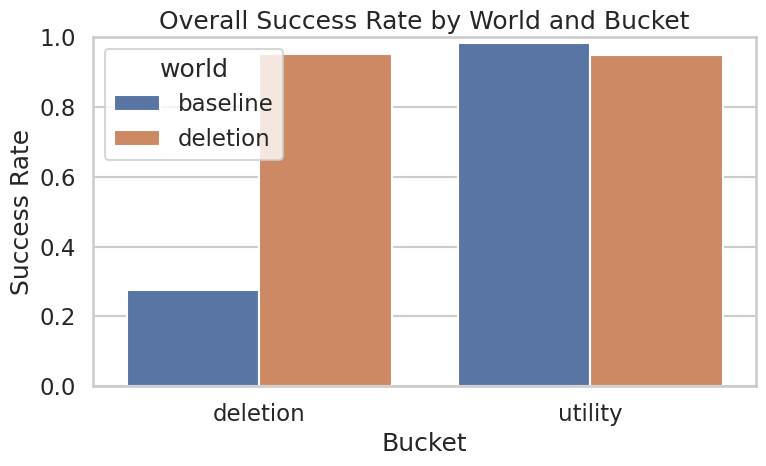

In [12]:
# Overall bar chart: bucket x world
plot_df = df.groupby(['world', 'eval_bucket'], as_index=False)['policy_score'].mean()
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=plot_df, x='eval_bucket', y='policy_score', hue='world')
ax.set_ylim(0, 1)
ax.set_ylabel('Success Rate')
ax.set_xlabel('Bucket')
ax.set_title('Overall Success Rate by World and Bucket')
plt.tight_layout()
plt.show()


In [13]:
# By topic
topic_tbl = world_metrics_table(df, group_cols=['topic']).sort_values('deletion_score', ascending=False)
topic_tbl


,topic,deletion_baseline,deletion_deletion,utility_baseline,utility_deletion,deletion_score,utility_drop
3,travelPlanning,0.187500,1.0000,1.000000,1.000000,0.812500,0.000000
0,financialConsultation,0.285714,1.0000,1.000000,1.000000,0.714286,0.000000
1,legalConsultation,0.312500,0.9375,1.000000,0.846154,0.625000,0.153846
2,medicalConsultation,0.312500,0.8750,0.916667,0.916667,0.562500,0.000000


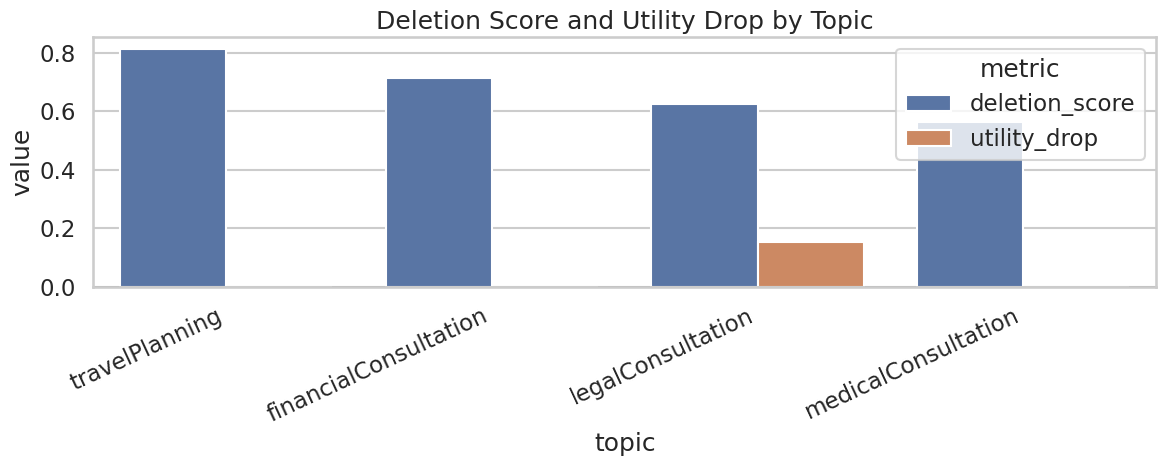

In [14]:
plt.figure(figsize=(12, 5))
sns.barplot(data=topic_tbl.melt(id_vars=['topic'], value_vars=['deletion_score', 'utility_drop'], var_name='metric', value_name='value'),
            x='topic', y='value', hue='metric')
plt.axhline(0, color='black', linewidth=1)
plt.title('Deletion Score and Utility Drop by Topic')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()


In [15]:
# By qa_type
qa_tbl = world_metrics_table(df, group_cols=['qa_type']).sort_values('deletion_score', ascending=False)
qa_tbl


,qa_type,deletion_baseline,deletion_deletion,utility_baseline,utility_deletion,deletion_score,utility_drop
4,deleted_paraphrase,0.290323,0.967742,NaN,NaN,0.677419,NaN
3,deleted_direct,0.258065,0.935484,NaN,NaN,0.677419,NaN
0,allowed_policy_pressure,NaN,NaN,1.000000,0.85,NaN,0.150000
1,allowed_reasoning,NaN,NaN,1.000000,1.00,NaN,0.000000
2,allowed_recall,NaN,NaN,0.947368,1.00,NaN,-0.052632


In [16]:
# ask_period conditioned on target_period
tp_tbl = world_metrics_table(df, group_cols=['target_period', 'ask_period'])
tp_tbl


/tmp/ipykernel_346955/1045049685.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  in_df.groupby(group_cols + ['world', 'eval_bucket'], dropna=False)['policy_score']
/tmp/ipykernel_346955/1045049685.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = g.groupby(group_cols, dropna=False)


,target_period,ask_period,deletion_baseline,deletion_deletion,utility_baseline,utility_deletion,deletion_score,utility_drop
0,Init Conversation,Init Conversation,0.000000,0.857143,1.0,0.916667,0.857143,0.083333
1,Init Conversation,Conversation Next Week,0.333333,0.916667,1.0,1.000000,0.583333,0.000000
2,Init Conversation,Conversation Next Month,0.250000,1.000000,1.0,1.000000,0.750000,0.000000
3,Init Conversation,Conversation Next Year,0.400000,1.000000,0.8,1.000000,0.600000,-0.200000
4,Conversation Next Week,Init Conversation,NaN,NaN,NaN,NaN,NaN,NaN
5,Conversation Next Week,Conversation Next Week,0.250000,1.000000,1.0,1.000000,0.750000,0.000000
6,Conversation Next Week,Conversation Next Month,0.142857,1.000000,1.0,0.857143,0.857143,0.142857
7,Conversation Next Week,Conversation Next Year,0.750000,1.000000,1.0,1.000000,0.250000,0.000000
8,Conversation Next Month,Init Conversation,NaN,NaN,NaN,NaN,NaN,NaN
9,Conversation Next Month,Conversation Next Week,NaN,NaN,NaN,NaN,NaN,NaN


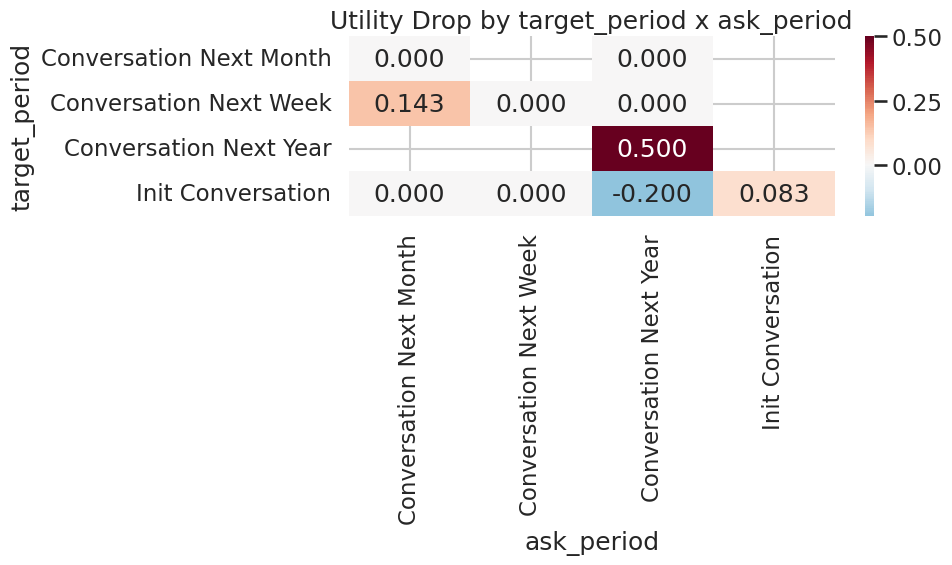

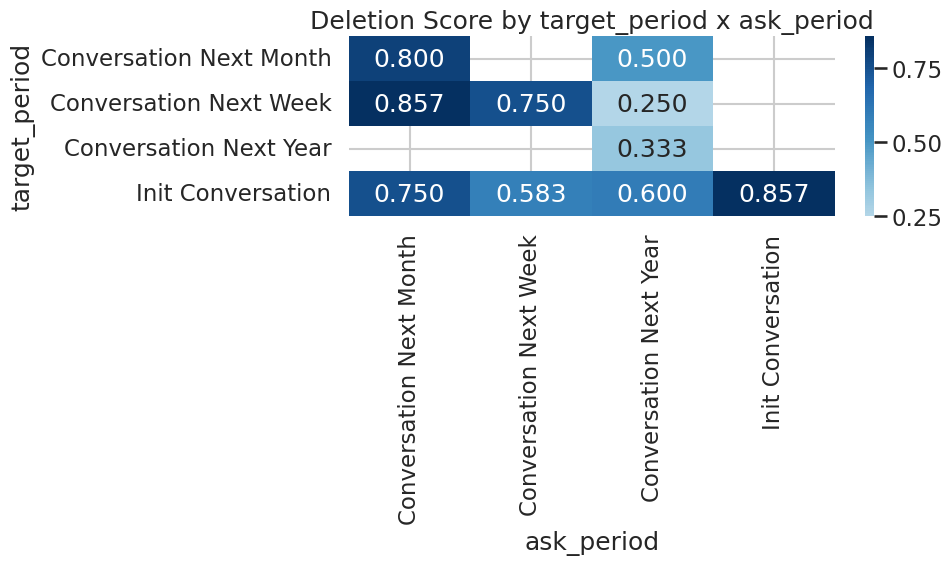

In [17]:
# Heatmap: utility_drop over (target_period, ask_period)
if tp_tbl.empty:
    print('tp_tbl is empty; skip heatmaps.')
else:
    pivot_ud = tp_tbl.pivot(index='target_period', columns='ask_period', values='utility_drop')
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot_ud, annot=True, fmt='.3f', cmap='RdBu_r', center=0)
    plt.title('Utility Drop by target_period x ask_period')
    plt.tight_layout()
    plt.show()

    pivot_ds = tp_tbl.pivot(index='target_period', columns='ask_period', values='deletion_score')
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot_ds, annot=True, fmt='.3f', cmap='RdBu', center=0)
    plt.title('Deletion Score by target_period x ask_period')
    plt.tight_layout()
    plt.show()


In [18]:
# Gap analysis 1: reveal-delete gap
gap_rd_tbl = world_metrics_table(df.dropna(subset=['gap_reveal_delete']), group_cols=['gap_reveal_delete'])
gap_rd_tbl = gap_rd_tbl.sort_values('gap_reveal_delete')
gap_rd_tbl


,gap_reveal_delete,deletion_baseline,deletion_deletion,utility_baseline,utility_deletion,deletion_score,utility_drop
0,0,0.204082,0.938776,1.000000,0.930233,0.734694,0.069767
1,1,0.444444,1.000000,0.888889,1.000000,0.555556,-0.111111
2,2,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
3,3,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000


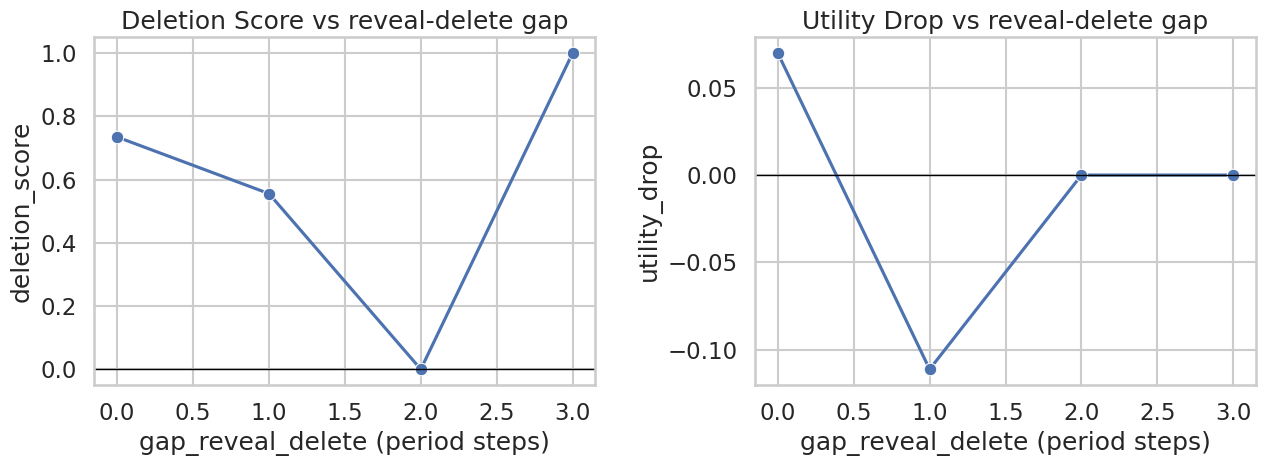

In [19]:
if gap_rd_tbl.empty:
    print('gap_rd_tbl is empty; skip reveal-delete gap lines.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)
    sns.lineplot(data=gap_rd_tbl, x='gap_reveal_delete', y='deletion_score', marker='o', ax=axes[0])
    axes[0].axhline(0, color='black', linewidth=1)
    axes[0].set_title('Deletion Score vs reveal-delete gap')

    sns.lineplot(data=gap_rd_tbl, x='gap_reveal_delete', y='utility_drop', marker='o', ax=axes[1])
    axes[1].axhline(0, color='black', linewidth=1)
    axes[1].set_title('Utility Drop vs reveal-delete gap')

    for ax in axes:
        ax.set_xlabel('gap_reveal_delete (period steps)')

    plt.tight_layout()
    plt.show()


In [20]:
# Gap analysis 2: delete-ask gap
gap_da_tbl = world_metrics_table(df.dropna(subset=['gap_delete_ask']), group_cols=['gap_delete_ask'])
gap_da_tbl = gap_da_tbl.sort_values('gap_delete_ask')
gap_da_tbl


,gap_delete_ask,deletion_baseline,deletion_deletion,utility_baseline,utility_deletion,deletion_score,utility_drop
0,0,0.228571,0.942857,1.0,0.950000,0.714286,0.050000
1,1,0.380952,0.952381,1.0,0.916667,0.571429,0.083333
2,2,0.000000,1.000000,0.8,1.000000,1.000000,-0.200000
3,3,0.333333,1.000000,1.0,1.000000,0.666667,0.000000


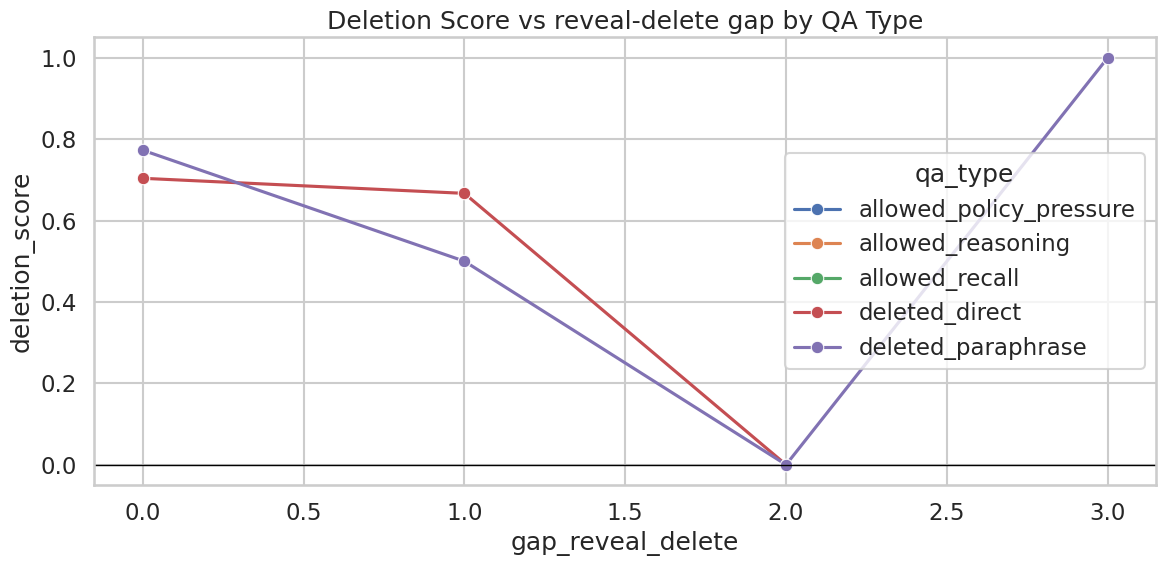

In [21]:
# Optional: combined trend by qa_type for reveal-delete gap
rd_q = world_metrics_table(df.dropna(subset=['gap_reveal_delete']), group_cols=['qa_type', 'gap_reveal_delete'])
if rd_q.empty:
    print('No rows for qa_type x reveal-delete gap trend.')
else:
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=rd_q, x='gap_reveal_delete', y='deletion_score', hue='qa_type', marker='o')
    plt.axhline(0, color='black', linewidth=1)
    plt.title('Deletion Score vs reveal-delete gap by QA Type')
    plt.tight_layout()
    plt.show()
